In [1]:
import fastplotlib as fpl
import os
import masknmf
import sys
import numpy as np

from ipywidgets import HBox, VBox
import math
import torch

##In the existing folder
import iblwfci_vis
import iblwfci_utils

from tqdm import tqdm
from one.api import ONE
from brainbox.io.one import SessionLoader
import matplotlib.pyplot as plt
one = ONE()

%load_ext autoreload

Unable to find extension: VK_EXT_acquire_drm_display
Unable to find extension: VK_EXT_physical_device_drm
No config found!
EGL says it can present to the window but not natively
Max vertex attribute stride unknown. Assuming it is 2048
Max vertex attribute stride unknown. Assuming it is 2048
Max vertex attribute stride unknown. Assuming it is 2048


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA TITAN RTX,DiscreteGPU,Vulkan,555.42.02
❗ limited,"llvmpipe (LLVM 12.0.0, 256 bits)",CPU,Vulkan,Mesa 21.2.6 (LLVM 12.0.0)
❌,NVIDIA TITAN RTX/PCIe/SSE2,Unknown,OpenGL,3.3.0 NVIDIA 555.42.02


Max vertex attribute stride unknown. Assuming it is 2048
Max vertex attribute stride unknown. Assuming it is 2048


In [2]:
"""
The two datasets from FD that we will process are: 
(1) 71ceb3d4-ca68-4380-8fe7-9f63d26222f6 (This is the existing FD_24/2023-06-07/001 data that I had already downloaded)
(2) 8df7b200-e44c-4c67-82e9-2666ba05d649 (This is the  FD_24/2023-06-08/001 data)
"""

'\nThe two datasets from FD that we will process are: \n(1) 71ceb3d4-ca68-4380-8fe7-9f63d26222f6 (This is the existing FD_24/2023-06-07/001 data that I had already downloaded)\n(2) 8df7b200-e44c-4c67-82e9-2666ba05d649 (This is the  FD_24/2023-06-08/001 data)\n'

# Step 1: Let's load the trial data we need from ONE to do the trial-triggered analysis 

In [21]:
eid = "71ceb3d4-ca68-4380-8fe7-9f63d26222f6"
sl = SessionLoader(eid = eid, one=one)
sl.load_trials()
print(sl.trials.keys())
stim_ontimes = sl.trials['stimOn_times']
firstMovement = sl.trials['firstMovement_times'].to_numpy()
feedback_times = sl.trials['feedback_times'].to_numpy()
# sl.load_motion_energy(views=["left"]) ## Load Motion Energy seems to fail here, not sure why 
sl.load_wheel()
imaging_times = one.load_dataset(eid, "imaging.times.npy", collection="alf/widefield")

/data/home/app2139/wfield/wfieldvenv/lib/python3.11/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "2026-01-16", ""
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


Index(['goCueTrigger_times', 'included', 'intervals_bpod_0',
       'intervals_bpod_1', 'quiescencePeriod', 'stimOffTrigger_times',
       'stimOff_times', 'stimOnTrigger_times', 'goCue_times', 'response_times',
       'choice', 'stimOn_times', 'contrastLeft', 'contrastRight',
       'feedback_times', 'feedbackType', 'rewardVolume', 'probabilityLeft',
       'firstMovement_times', 'intervals_0', 'intervals_1'],
      dtype='object')


In [17]:
np.std(sl.wheel['velocity'].to_numpy())

np.float32(0.9843298)

In [25]:
def keep_separated(timepoints, min_sep=2.0):
    """
    Keep a subset of timepoints such that each is at least `min_sep`
    seconds apart from the previously kept one.

    Parameters
    ----------
    timepoints : array-like
        List or array of timepoints (in seconds).
    min_sep : float
        Minimum separation in seconds.

    Returns
    -------
    kept : list
        Subset of timepoints satisfying the separation constraint.
    """
    if len(timepoints) == 0:
        return []

    # Ensure sorted order
    timepoints = sorted(timepoints)

    kept = [timepoints[0]]
    last = timepoints[0]

    for t in timepoints[1:]:
        if t - last >= min_sep:
            kept.append(t)
            last = t

    return kept

def load_wheel_speed_trials(wheel_info, imaging_times):
    times = wheel_info['times'].to_numpy()
    velocity = wheel_info['velocity'].to_numpy()

    selector = np.logical_and(times > 5, np.abs(velocity) > 5)
    selector = np.logical_and(selector, times < np.amax(imaging_times) - 100) #Guarantee we are still in the right window
    subset_times = times[selector]
    subset_times = keep_separated(subset_times, min_sep=2.0)
    return np.array(subset_times)

wheel_trials = load_wheel_speed_trials(sl.wheel, imaging_times)
print(len(wheel_trials))

194


In [40]:
trial_indices = np.searchsorted(imaging_times, wheel_trials)
trial_indices = (trial_indices // 2) ##This is correct if the functional channel is 0. If it is 1, you need to adjust it

In [28]:
np.amax(stim_ontimes)

np.float64(4255.434033333333)

In [27]:
np.amax(wheel_trials)

np.float32(4158.013)

In [29]:
np.amax(imaging_times)

np.float64(4262.038866666667)

In [51]:
print(np.amin(wheel_trials[1:] - wheel_trials[:-1]))

2.0


In [35]:
firstMovement = firstMovement[~np.isnan(firstMovement)]

In [53]:
feedback_times = feedback_times[~np.isnan(feedback_times)]

In [51]:
type(feedback_times)

pandas.core.series.Series

In [90]:
print(np.amax(trial_indices))
print(hemocorr_pmd.shape[0])

111054
133053


# Step 2: Let's load the stacks we need (from Joao's method and Amol's method) to study trial-trigged signal

In [5]:
## Let's load the 007 folder data (masknmf processing results)
hemocorr_pmd = masknmf.PMDArray.from_hdf5("felicia_jan_26_007/hemocorr.hdf5")
hemocorr_pmd.to('cuda')
hemocorr_pmd.rescale = True

In [6]:
parent_path = "/data/lab/IBL_Alyx/churchlandlab_ucla/Subjects/FD_24/2023-06-07/001/raw_widefield_data"
u_path = os.path.join(parent_path, "U.npy")
svt_path = os.path.join(parent_path, "SVT.npy")
svtcorr_path = os.path.join(parent_path, "SVTcorr.npy")
frames_avg_path = os.path.join(parent_path, "frames_average.npy")

manual_mask = np.load(os.path.join(parent_path, "manual_mask.npy"))

In [7]:
joao_gcamp, joao_blood, joao_hemocorr = iblwfci_utils.load_joao_results(u_path,
                  svt_path,
                  svtcorr_path,
                  frames_avg_path,
                  functional_channel = 0)

In [8]:
joao_gcamp.rescale = True
joao_blood.rescale = True
joao_hemocorr.rescale = True

joao_gcamp.to('cuda')
joao_blood.to('cuda')
joao_hemocorr.to('cuda')

In [9]:
def get_trial_triggered_stack(my_pmd_movie, trial_indices, before_frames = 20, after_frames = 100, device='cpu'):
    my_pmd_movie.to(device)
    average_movie = torch.zeros((before_frames + after_frames, my_pmd_movie.shape[1], my_pmd_movie.shape[2])).to(device)
    num_trials = trial_indices.shape[0]
    for k in tqdm(range(trial_indices.shape[0])):
        curr_ind = trial_indices[k]
        curr_data = my_pmd_movie.getitem_tensor(slice(curr_ind - before_frames, curr_ind + after_frames))
        curr_data /= num_trials
        average_movie += curr_data 
    return average_movie.cpu().numpy()


In [183]:
def compute_average_trial_correlations(trial_avg_movie: np.ndarray,
                                       my_pmd_movie,
                                       trial_indices,
                                       mask = None,
                                       before_frames = 20,
                                       after_frames = 80,
                                       device = 'cuda'):

    if mask is None:
        mask = torch.ones(my_pmd_movie.shape[1], my_pmd_movie.shape[2]).float().to(device)
    else:
        mask = torch.from_numpy(mask).float().to(device)
    my_pmd_movie.to(device)
    average_movie = torch.from_numpy(trial_avg_movie).to(device).float() * mask[None, :, :]
    average_movie -= torch.mean(average_movie, dim = 0, keepdim=True)
    average_movie /= torch.linalg.norm(average_movie, dim=0, keepdim=True)
    average_movie = torch.nan_to_num(average_movie, nan = 0.0)
    average_correlation = torch.zeros(my_pmd_movie.shape[1], my_pmd_movie.shape[2], device=device).float()
    num_trials = trial_indices.shape[0]
    avg_list = []
    for k in tqdm(range(trial_indices.shape[0])):
        curr_ind = trial_indices[k]
        curr_data = my_pmd_movie.getitem_tensor(slice(curr_ind - before_frames, curr_ind + after_frames)) * mask[None, :, :]
        curr_data -= torch.mean(curr_data, dim=0, keepdim=True)
        curr_data /= torch.linalg.norm(curr_data, dim=0, keepdim=True)
        curr_data = torch.nan_to_num(curr_data, nan = 0.0)
        temp = (torch.sum(curr_data * average_movie, dim = 0))
        avg_list.append(torch.amax(temp[mask >= 0]).cpu().numpy())
        average_correlation += (torch.nan_to_num(temp, nan = 0.0) / num_trials)

    return average_correlation.cpu().numpy(), np.array(avg_list)

In [41]:
before_frames = 20
after_frames = 80

In [42]:
joao_trial_avg = get_trial_triggered_stack(joao_hemocorr, trial_indices, before_frames = before_frames, after_frames = after_frames, device='cuda')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 194/194 [00:11<00:00, 16.41it/s]


In [43]:
amol_trial_avg = get_trial_triggered_stack(hemocorr_pmd, trial_indices, before_frames = before_frames, after_frames = after_frames, device='cuda')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 194/194 [00:02<00:00, 84.27it/s]


RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
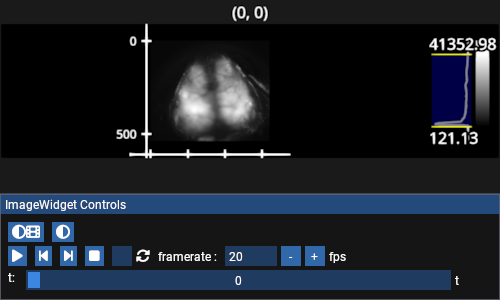

In [129]:
iw = fpl.ImageWidget(data = amol_trial_avg)
iw.cmap = "gray"
iw.show()

In [44]:
joao_trial_avg = joao_trial_avg - np.mean(joao_trial_avg, axis = 0, keepdims = True)
amol_trial_avg = amol_trial_avg - np.mean(amol_trial_avg, axis = 0, keepdims = True)


In [51]:
# View results
iblwfci_vis.raster_view(amol_trial_avg, joao_trial_avg, 5)

In [16]:
trial_temp = trial_indices[:, None] + np.arange(-20, 80)[None, :]

In [20]:
trial_temp.flatten()

array([  1698,   1699,   1700, ..., 132422, 132423, 132424],
      shape=(85600,))

In [47]:
def trial_triggered_view(img_stack_1, 
                         img_stack_2, 
                         full_img_stack_1, 
                         full_img_stack_2, 
                         trial_data, 
                         before_event=20, 
                         after_event=80,
                        img_names = ['Amol', 'Joao'],
                        raster_names = ['Amol', 'Joao']):
    ## This gives a basic GUI that allows us to look at two sets of videos. Double click on the top panels and in the bottom panel a rastermap of a local region of pixels will pop up

    trial_indices = trial_data[:, None] + np.arange(-1*before_event, after_event)[None, :]
    trial_indices_f = trial_indices.flatten()
    
        
    num_frames = img_stack_1.shape[0]
    data_shape = img_stack_1.shape[1], img_stack_1.shape[2]
    
    start_coordinates = (data_shape[0] // 2, data_shape[1] // 2)

    def compute_raster_stack(my_stack, y, x):
        time_series = my_stack[:, y, x]
        z = time_series[trial_indices_f].reshape(trial_indices.shape)
        return z
        

    raster_1 = compute_raster_stack(full_img_stack_1, start_coordinates[0], start_coordinates[1])
    raster_2 = compute_raster_stack(full_img_stack_2, start_coordinates[0], start_coordinates[1])
    
    movie_widget = fpl.ImageWidget(data = [img_stack_1, 
                                    img_stack_2],
                           names = img_names)
    movie_widget.cmap = "gray"

    raster_widget = fpl.ImageWidget(data = [raster_1,
                                            raster_2],
                                    names = raster_names)
    raster_widget.cmap = "gray"

    rect_selector_kwargs = dict(
                edge_thickness=1,
                edge_color="w",
                vertex_size=3.0,
                vertex_color="cyan"
            )
    
    sel_1 = movie_widget.managed_graphics[0].add_rectangle_selector(
                    selection=[start_coordinates[1], start_coordinates[1] + 1, start_coordinates[0], start_coordinates[0] + 1],
                    **rect_selector_kwargs
                )
    
    sel_2 = movie_widget.managed_graphics[1].add_rectangle_selector(
                     selection=[start_coordinates[1], start_coordinates[1] + 1, start_coordinates[0], start_coordinates[0] + 1],
                    **rect_selector_kwargs
                )

    time_sel_1 = raster_widget.managed_graphics[0].add_linear_selector(0, axis="x")
    time_sel_2 = raster_widget.managed_graphics[1].add_linear_selector(0, axis="x")
    
    def update_values(ev):
        x, y = ev.pick_info['index']

        raster_1  = compute_raster_stack(full_img_stack_1, y, x)
        raster_2 = compute_raster_stack(full_img_stack_2, y, x)

    
        sel_1.selection = [x, x+1, y, y+1]
        sel_2.selection = [x, x+1, y, y+1]
        raster_widget.managed_graphics[0].data = raster_1
        raster_widget.managed_graphics[1].data = raster_2

    def temporal_sync(ev):
        ## First implementation will be selector --> widget (change the selector, update widget)

        ##In this case, the event came from imagewidget
        if isinstance(ev, dict):
            curr_index = int(ev['t'])
            time_sel_1.selection = curr_index
            time_sel_2.selection = curr_index
            
        else:
            curr_index = math.floor(ev.info['value'])

            time_sel_1.selection = curr_index
            time_sel_2.selection = curr_index
            movie_widget.current_index = {'t': curr_index}
    
    
    movie_widget.managed_graphics[0].add_event_handler(update_values, "double_click")
    movie_widget.managed_graphics[1].add_event_handler(update_values, "double_click")

    time_sel_1.add_event_handler(temporal_sync, "selection")
    time_sel_2.add_event_handler(temporal_sync, "selection")
    movie_widget.add_event_handler(temporal_sync, "current_index")
    
    
    return VBox([movie_widget.show(), raster_widget.show()])

In [49]:
# trial_triggered_view(amol_trial_avg, 
#                      joao_trial_avg,
#                      hemocorr_pmd,
#                      joao_hemocorr,
#                      trial_indices)